In [2]:
# In R Colab, we upload using this method
library(htmltools)

# First install what we need
install.packages("sqldf", repos="https://cran.r-project.org", quiet=TRUE)
install.packages("ggplot2", repos="https://cran.r-project.org", quiet=TRUE)
install.packages("dplyr", repos="https://cran.r-project.org", quiet=TRUE)

cat("Packages installed! Now upload your files.\n")

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’




Packages installed! Now upload your files.


In [3]:
# Upload files the easy way in R Colab
source_python <- function() {
  reticulate::py_run_string("
from google.colab import files
uploaded = files.upload()
")
}

install.packages("reticulate", repos="https://cran.r-project.org", quiet=TRUE)
library(reticulate)
py_run_string("
from google.colab import files
files.upload()
")

also installing the dependencies ‘RcppTOML’, ‘here’, ‘png’



Attaching package: ‘reticulate’


The following object is masked _by_ ‘.GlobalEnv’:

    source_python




ERROR: No module named 'google'

In [2]:
library(sqldf)
library(ggplot2)
library(dplyr)

customers  <- read.csv("customers.csv")
orders     <- read.csv("orders.csv")
deliveries <- read.csv("deliveries.csv")
complaints <- read.csv("complaints.csv")
drivers    <- read.csv("drivers.csv")
hubs       <- read.csv("hubs.csv")

cat("All files loaded!\n")
cat("Customers:", nrow(customers), "rows\n")
cat("Orders:", nrow(orders), "rows\n")
cat("Deliveries:", nrow(deliveries), "rows\n")
cat("Complaints:", nrow(complaints), "rows\n")

ERROR: Error in library(sqldf): there is no package called ‘sqldf’


In [3]:
install.packages("sqldf", repos="https://cran.r-project.org")
install.packages("ggplot2", repos="https://cran.r-project.org")
install.packages("dplyr", repos="https://cran.r-project.org")

cat("All packages installed!\n")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



All packages installed!


In [4]:
library(sqldf)
library(ggplot2)
library(dplyr)

customers  <- read.csv("customers.csv")
orders     <- read.csv("orders.csv")
deliveries <- read.csv("deliveries.csv")
complaints <- read.csv("complaints.csv")
drivers    <- read.csv("drivers.csv")
hubs       <- read.csv("hubs.csv")

cat("All files loaded!\n")
cat("Customers:", nrow(customers), "rows\n")
cat("Orders:", nrow(orders), "rows\n")
cat("Deliveries:", nrow(deliveries), "rows\n")
cat("Complaints:", nrow(complaints), "rows\n")

Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




All files loaded!
Customers: 650 rows
Orders: 1250 rows
Deliveries: 950 rows
Complaints: 320 rows


In [5]:
# SQL QUERY 1: Which complaint types happen most often?
query1 <- sqldf("
  SELECT complaint_type,
         COUNT(*) AS total_complaints,
         ROUND(AVG(resolution_days), 1) AS avg_days_to_resolve
  FROM complaints
  GROUP BY complaint_type
  ORDER BY total_complaints DESC
")

print(query1)

     complaint_type total_complaints avg_days_to_resolve
1             Delay              101                 7.3
2      MissedPickup               64                 7.6
3          AppIssue               53                 8.6
4   DriverBehaviour               51                 8.2
5 SupportExperience               20                 7.5
6           Billing               16                 7.8
7            Damage               15                11.3


In [6]:
# SQL QUERY 2: Which hubs have the most failed deliveries?
query2 <- sqldf("
  SELECT d.hub_id,
         h.hub_name,
         h.zone,
         COUNT(*) AS total_deliveries,
         SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failed_deliveries,
         ROUND(AVG(d.customer_rating_post_delivery), 2) AS avg_rating
  FROM deliveries d
  JOIN hubs h ON d.hub_id = h.hub_id
  GROUP BY d.hub_id
  ORDER BY failed_deliveries DESC
")

print(query2)

  hub_id       hub_name      zone total_deliveries failed_deliveries avg_rating
1    H08  Midtown Relay   Central              128                26       3.88
2    H05   Central Core   Central              115                23       3.67
3    H01 North Exchange     North              136                17       3.84
4    H04      West Gate      West              127                16       3.92
5    H06    Airport Hub   Airport              104                15       3.88
6    H07  Riverside Hub Riverside              115                14       3.88
7    H03      East Dock      East              119                11       3.90
8    H02     South Link     South              106                10       3.95


In [7]:
# SQL QUERY 3: Which customers have the most complaints and highest order values?
query3 <- sqldf("
  SELECT c.customer_id,
         c.customer_type,
         c.home_zone,
         COUNT(DISTINCT o.order_id) AS total_orders,
         ROUND(SUM(o.order_value), 2) AS total_spent,
         COUNT(DISTINCT comp.complaint_id) AS total_complaints
  FROM customers c
  LEFT JOIN orders o ON c.customer_id = o.customer_id
  LEFT JOIN complaints comp ON c.customer_id = comp.customer_id
  GROUP BY c.customer_id
  HAVING total_complaints > 0
  ORDER BY total_complaints DESC, total_spent DESC
  LIMIT 10
")

print(query3)

   customer_id customer_type home_zone total_orders total_spent
1        C0368      Consumer     North            3      943.68
2        C0545      Consumer     SOUTH            6     2770.35
3        C0372      Consumer      West            6     2007.33
4        C0172      Consumer     north            4     1727.52
5        C0421      Consumer   CENTRAL            3      995.73
6        C0626      Consumer     SOUTH            3      919.98
7        C0110      Consumer      EAST            3      912.27
8        C0242      Consumer      East            5      794.58
9        C0282      Consumer RiverSide            2      743.64
10       C0142      Consumer     SOUTH            2      633.00
   total_complaints
1                 4
2                 3
3                 3
4                 3
5                 3
6                 3
7                 3
8                 3
9                 3
10                3


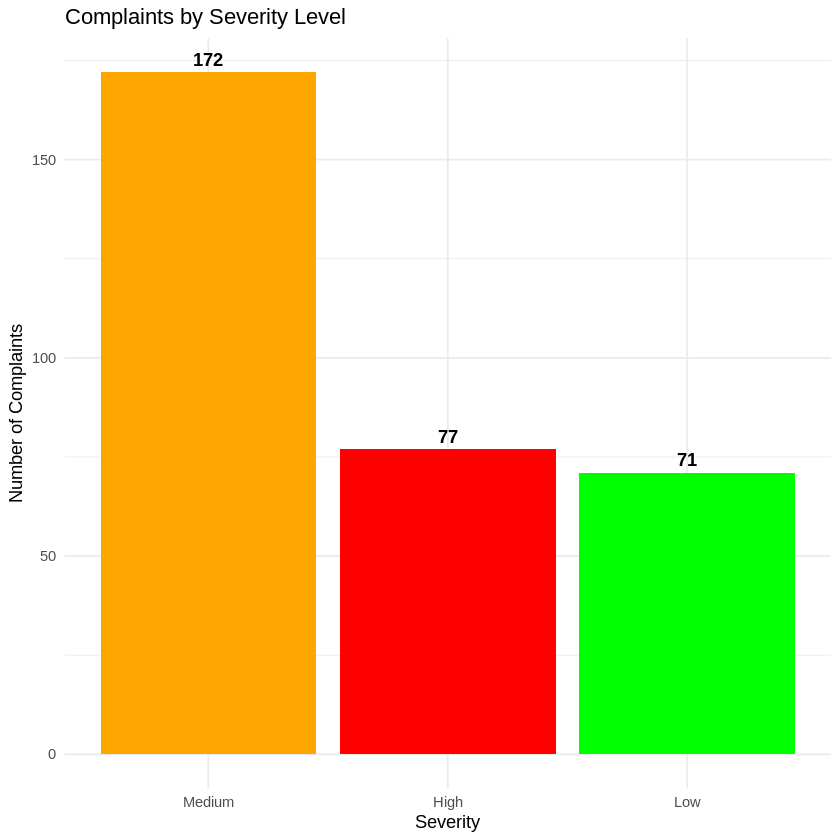

In [8]:
# R CHART 1: Complaint severity breakdown
severity_counts <- complaints %>%
  group_by(severity) %>%
  summarise(count = n()) %>%
  arrange(desc(count))

ggplot(severity_counts, aes(x = reorder(severity, -count), y = count, fill = severity)) +
  geom_bar(stat = "identity") +
  geom_text(aes(label = count), vjust = -0.5, fontface = "bold") +
  scale_fill_manual(values = c("High" = "red", "Medium" = "orange", "Low" = "green")) +
  labs(title = "Complaints by Severity Level",
       x = "Severity", y = "Number of Complaints") +
  theme_minimal() +
  theme(legend.position = "none")

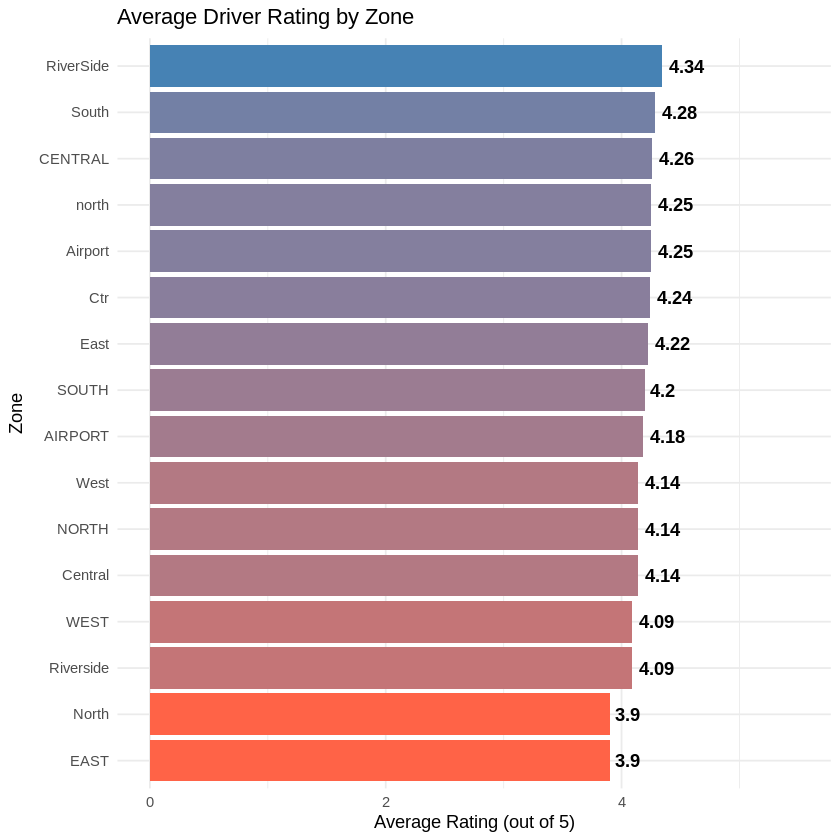

In [9]:
# R CHART 2: Average driver rating by zone
driver_zone_rating <- drivers %>%
  group_by(base_zone) %>%
  summarise(avg_rating = round(mean(driver_rating, na.rm = TRUE), 2)) %>%
  arrange(avg_rating)

ggplot(driver_zone_rating, aes(x = reorder(base_zone, avg_rating), y = avg_rating, fill = avg_rating)) +
  geom_bar(stat = "identity") +
  geom_text(aes(label = avg_rating), hjust = -0.2, fontface = "bold") +
  coord_flip() +
  scale_fill_gradient(low = "tomato", high = "steelblue") +
  labs(title = "Average Driver Rating by Zone",
       x = "Zone", y = "Average Rating (out of 5)") +
  theme_minimal() +
  theme(legend.position = "none") +
  ylim(0, 5.5)

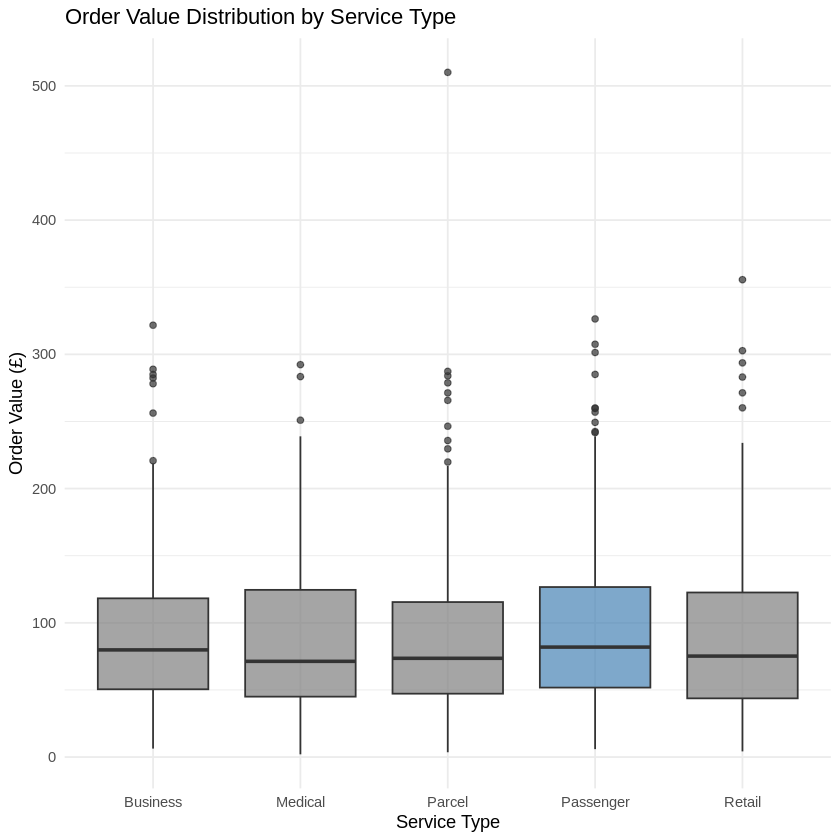

In [10]:
# R CHART 3: Distribution of order values by service type
ggplot(orders, aes(x = service_type, y = order_value, fill = service_type)) +
  geom_boxplot(alpha = 0.7) +
  scale_fill_manual(values = c("Passenger" = "steelblue",
                                "Delivery" = "darkorange",
                                "Warehouse" = "green")) +
  labs(title = "Order Value Distribution by Service Type",
       x = "Service Type", y = "Order Value (£)") +
  theme_minimal() +
  theme(legend.position = "none")

In [1]:
# R STATISTICAL ANALYSIS
print("=== STATISTICAL SUMMARY ===")

# Summary statistics for deliveries
cat("\n--- Delivery Route Distance (km) ---\n")
cat("Mean:   ", round(mean(deliveries$route_distance_km), 2), "km\n")
cat("Median: ", round(median(deliveries$route_distance_km), 2), "km\n")
cat("Std Dev:", round(sd(deliveries$route_distance_km), 2), "km\n")

# Summary statistics for customer ratings
cat("\n--- Customer Ratings (out of 5) ---\n")
cat("Mean:   ", round(mean(deliveries$customer_rating_post_delivery, na.rm=TRUE), 2), "\n")
cat("Median: ", round(median(deliveries$customer_rating_post_delivery, na.rm=TRUE), 2), "\n")
cat("Std Dev:", round(sd(deliveries$customer_rating_post_delivery, na.rm=TRUE), 2), "\n")

# Complaint resolution days by severity
cat("\n--- Avg Resolution Days by Severity ---\n")
resolution_stats <- complaints %>%
  group_by(severity) %>%
  summarise(
    count = n(),
    avg_days = round(mean(resolution_days, na.rm=TRUE), 1),
    median_days = round(median(resolution_days, na.rm=TRUE), 1)
  )
print(resolution_stats)

# Driver experience vs rating correlation
corr_val <- cor(drivers$years_experience, drivers$driver_rating, use="complete.obs")
cat("\n--- Correlation: Driver Experience vs Rating ---\n")
cat("Correlation:", round(corr_val, 4), "\n")
cat("Interpretation: Values close to 1 = strong positive link\n")

[1] "=== STATISTICAL SUMMARY ==="

--- Delivery Route Distance (km) ---


ERROR: Error: object 'deliveries' not found


In [2]:
library(sqldf)
library(ggplot2)
library(dplyr)

customers  <- read.csv("customers.csv")
orders     <- read.csv("orders.csv")
deliveries <- read.csv("deliveries.csv")
complaints <- read.csv("complaints.csv")
drivers    <- read.csv("drivers.csv")
hubs       <- read.csv("hubs.csv")

cat("Data reloaded!\n")

ERROR: Error in library(sqldf): there is no package called ‘sqldf’


In [3]:
install.packages("sqldf", repos="https://cran.r-project.org")
install.packages("ggplot2", repos="https://cran.r-project.org")
install.packages("dplyr", repos="https://cran.r-project.org")
cat("Done!\n")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



Done!


In [4]:
library(sqldf)
library(ggplot2)
library(dplyr)

customers  <- read.csv("customers.csv")
orders     <- read.csv("orders.csv")
deliveries <- read.csv("deliveries.csv")
complaints <- read.csv("complaints.csv")
drivers    <- read.csv("drivers.csv")
hubs       <- read.csv("hubs.csv")

cat("Data reloaded!\n")
cat("Deliveries:", nrow(deliveries), "rows\n")

Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message in file(file, "rt"):
“cannot open file 'customers.csv': No such file or directory”


ERROR: Error in file(file, "rt"): cannot open the connection


In [5]:
library(sqldf)
library(ggplot2)
library(dplyr)

customers  <- read.csv("customers.csv")
orders     <- read.csv("orders.csv")
deliveries <- read.csv("deliveries.csv")
complaints <- read.csv("complaints.csv")
drivers    <- read.csv("drivers.csv")
hubs       <- read.csv("hubs.csv")

cat("Data reloaded!\n")
cat("Deliveries:", nrow(deliveries), "rows\n")

Warning message in file(file, "rt"):
“cannot open file 'customers.csv': No such file or directory”


ERROR: Error in file(file, "rt"): cannot open the connection


In [6]:
library(sqldf)
library(ggplot2)
library(dplyr)

customers  <- read.csv("customers.csv")
orders     <- read.csv("orders.csv")
deliveries <- read.csv("deliveries.csv")
complaints <- read.csv("complaints.csv")
drivers    <- read.csv("drivers.csv")
hubs       <- read.csv("hubs.csv")

cat("Data reloaded!\n")
cat("Deliveries:", nrow(deliveries), "rows\n")

Data reloaded!
Deliveries: 950 rows


In [7]:
# R STATISTICAL ANALYSIS
print("=== STATISTICAL SUMMARY ===")

cat("\n--- Delivery Route Distance (km) ---\n")
cat("Mean:   ", round(mean(deliveries$route_distance_km), 2), "km\n")
cat("Median: ", round(median(deliveries$route_distance_km), 2), "km\n")
cat("Std Dev:", round(sd(deliveries$route_distance_km), 2), "km\n")

cat("\n--- Customer Ratings (out of 5) ---\n")
cat("Mean:   ", round(mean(deliveries$customer_rating_post_delivery, na.rm=TRUE), 2), "\n")
cat("Median: ", round(median(deliveries$customer_rating_post_delivery, na.rm=TRUE), 2), "\n")
cat("Std Dev:", round(sd(deliveries$customer_rating_post_delivery, na.rm=TRUE), 2), "\n")

cat("\n--- Avg Resolution Days by Severity ---\n")
resolution_stats <- complaints %>%
  group_by(severity) %>%
  summarise(
    count = n(),
    avg_days = round(mean(resolution_days, na.rm=TRUE), 1),
    median_days = round(median(resolution_days, na.rm=TRUE), 1)
  )
print(resolution_stats)

corr_val <- cor(drivers$years_experience, drivers$driver

ERROR: Error in parse(text = input): <text>:25:0: unexpected end of input
23: 
24: corr_val <- cor(drivers$years_experience, drivers$driver
   ^


In [8]:
library(dplyr)

cat("--- Delivery Route Distance (km) ---\n")
cat("Mean:   ", round(mean(deliveries$route_distance_km), 2), "km\n")
cat("Median: ", round(median(deliveries$route_distance_km), 2), "km\n")
cat("Std Dev:", round(sd(deliveries$route_distance_km), 2), "km\n")

cat("\n--- Customer Ratings (out of 5) ---\n")
cat("Mean:   ", round(mean(deliveries$customer_rating_post_delivery, na.rm=TRUE), 2), "\n")
cat("Median: ", round(median(deliveries$customer_rating_post_delivery, na.rm=TRUE), 2), "\n")
cat("Std Dev:", round(sd(deliveries$customer_rating_post_delivery, na.rm=TRUE), 2), "\n")

--- Delivery Route Distance (km) ---
Mean:    13.91 km
Median:  12.84 km
Std Dev: 7.48 km

--- Customer Ratings (out of 5) ---
Mean:    3.86 
Median:  4.04 
Std Dev: 0.89 


In [9]:
cat("--- Avg Resolution Days by Severity ---\n")
resolution_stats <- complaints %>%
  group_by(severity) %>%
  summarise(
    count = n(),
    avg_days = round(mean(resolution_days, na.rm=TRUE), 1),
    median_days = round(median(resolution_days, na.rm=TRUE), 1)
  )
print(resolution_stats)

corr_val <- cor(drivers$years_experience, drivers$driver_rating, use="complete.obs")
cat("\n--- Correlation: Driver Experience vs Rating ---\n")
cat("Correlation:", round(corr_val, 4), "\n")
cat("Interpretation: Values close to 1 = strong positive link\n")

--- Avg Resolution Days by Severity ---
# A tibble: 3 × 4
  severity count avg_days median_days
  <chr>    <int>    <dbl>       <dbl>
1 High        77     13.1          12
2 Low         71      6.6           6
3 Medium     172      6.2           6

--- Correlation: Driver Experience vs Rating ---
Correlation: 0.0628 
Interpretation: Values close to 1 = strong positive link
